In [24]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [25]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# This line makes SHAP plots render correctly inside Jupyter
shap.initjs()

print(f"SHAP version: {shap.__version__}")
print(" All imports successful")

SHAP version: 0.51.0
 All imports successful


In [26]:
# Import your existing helpers
from production_train_model import load_production_model, predict_stress, PROD_MODEL_DIR
from data_loader import load_dataset

print(f"Production models directory: {PROD_MODEL_DIR}")
print(" Project helpers loaded")

Production models directory: /home/rs/ml-projects/training_system/saved_production_models
 Project helpers loaded


In [27]:
# ── CONFIGURE HERE ────────────────────────────────────────────────────────
MODEL_NAME = "xgboost"     
EXPERIMENT = "chest_all"    # Change this to any experiment name such as wrist_all

# Corresponding data config (matches EXPERIMENTS dict in production_train_model.py)
EXPERIMENT_CONFIGS = {
    "chest_acc":         {"chest": ["acc"]},
    "chest_eda":         {"chest": ["eda"]},
    "chest_emg":         {"chest": ["emg"]},
    "chest_heart":       {"chest": ["heart"]},
    "chest_statistical": {"chest": ["statistical"]},
    "wrist_acc":         {"wrist": ["acc"]},
    "wrist_eda":         {"wrist": ["eda"]},
    "wrist_heart":       {"wrist": ["heart"]},
    "wrist_statistical": {"wrist": ["statistical"]},
    "chest_all":         {"chest": ["acc", "eda", "emg", "heart", "statistical"]},
    "wrist_all":         {"wrist": [ "acc","eda", "heart", "statistical"]},
}

DATA_CONFIG = EXPERIMENT_CONFIGS[EXPERIMENT]
NON_FEATURE_COLS = ["label", "subject", "window_idx", "start_time", "end_time"]

display(f"Model    : {MODEL_NAME}")
display(f"Experiment: {EXPERIMENT}")
display(f"Data config: {DATA_CONFIG}")

'Model    : xgboost'

'Experiment: chest_all'

"Data config: {'chest': ['acc', 'eda', 'emg', 'heart', 'statistical']}"

In [28]:
model, scaler, medians, meta = load_production_model(MODEL_NAME, EXPERIMENT)

print("=" * 50)
print(f"Model type    : {type(model).__name__}")
print(f"Num features  : {meta['n_features']}")
print(f"Num subjects  : {meta['n_subjects']}")
print(f"Num windows   : {meta['n_windows']}")
print(f"Label map     : {meta['label_map']}")
print(f"Label counts  : {meta['label_counts']}")
print("=" * 50)

feature_names = meta["feature_names"]
display(f"\nFirst 10 features: {feature_names[:10]}")

Model type    : XGBClassifier
Num features  : 170
Num subjects  : 15
Num windows   : 975
Label map     : {'0': 'baseline', '1': 'stress'}
Label counts  : {'0': 613, '1': 362}


"\nFirst 10 features: ['chest_acc_x_mean_x', 'chest_acc_x_std_x', 'chest_acc_x_min_x', 'chest_acc_x_max_x', 'chest_acc_x_range_x', 'chest_acc_x_abs_integral_x', 'chest_acc_y_mean_x', 'chest_acc_y_std_x', 'chest_acc_y_min_x', 'chest_acc_y_max_x']"

## Cell 5: Load & Prepare Data for SHAP

### Why do we need data for SHAP?

SHAP needs a **background dataset** (the data the model was trained on, or a sample of it) to compute expected values.  
For XGBoost, SHAP uses the actual tree structure so it's very fast even on large datasets.

> **Note:** We apply the same preprocessing pipeline (impute → scale) before passing to SHAP.

In [29]:
# Load the full dataset
df = load_dataset(DATA_CONFIG)
print(f"Dataset shape: {df.shape}")
print(f"Subjects: {sorted(df['subject'].unique())}")

# Separate features and labels
X_raw = df.drop(columns=NON_FEATURE_COLS)
y     = df["label"]

# Apply the same preprocessing as training:
# 1. Impute NaNs with training medians
X_imputed = X_raw[feature_names].fillna(medians)

# 2. Scale with training scaler
X_scaled = scaler.transform(X_imputed)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

display(f"\nFeature matrix shape: {X_scaled_df.shape}")
display(f"Stress windows  : {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")
display(f"Baseline windows: {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")

Dataset shape: (975, 175)
Subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


'\nFeature matrix shape: (975, 170)'

'Stress windows  : 362 (37.1%)'

'Baseline windows: 613 (62.9%)'

## Cell 6: Create the SHAP Explainer

### Which SHAP explainer should  use?

| Explainer | Best for | Speed |
|-----------|----------|-------|
| `TreeExplainer` | XGBoost, LightGBM, RandomForest |  Very fast |
| `LinearExplainer` | Linear/Logistic regression |  Fast |
| `KernelExplainer` | Any model |  Slow |

Since we're using **XGBoost**, `TreeExplainer` is the perfect choice  it directly traverses the tree structure.

### What is `shap_values`?
It's a matrix of shape `(n_samples, n_features)`.  
Each value tells you: *"For this specific sample, this feature contributed X amount to the prediction."*
- **Positive value** → pushed prediction toward **stress**
- **Negative value** → pushed prediction toward **baseline**

In [30]:
print("Computing SHAP values... ")

# TreeExplainer is optimized for XGBoost — uses exact tree path computation
explainer = shap.TreeExplainer(model)

# Compute SHAP values for all samples
# shap_values shape: (n_samples, n_features)
# For binary classification, XGBoost returns values in log-odds space
shap_values = explainer.shap_values(X_scaled_df)

# Also get the Explanation object (needed for some newer SHAP plots)
shap_explanation = explainer(X_scaled_df)

print(f"\n SHAP values computed!")
display(f"Shape of shap_values: {shap_values.shape}")
display(f"   {shap_values.shape[0]} windows × {shap_values.shape[1]} features")
display(f"\nExpected value (base rate): {explainer.expected_value:.4f}")
display("   This is the model's average prediction (in log-odds for XGBoost)")

Computing SHAP values... 

 SHAP values computed!


'Shape of shap_values: (975, 170)'

'   975 windows × 170 features'

'\nExpected value (base rate): -0.5466'

"   This is the model's average prediction (in log-odds for XGBoost)"

## Cell 7: Global Feature Importance  Bar Plot

**What it shows:** The average magnitude of SHAP values per feature across all samples.  
**How to read it:** Features at the top are the most influential globally  they move predictions the most, on average.  

> This is similar to XGBoost's built-in feature importance, but more reliable because it accounts for feature interactions.

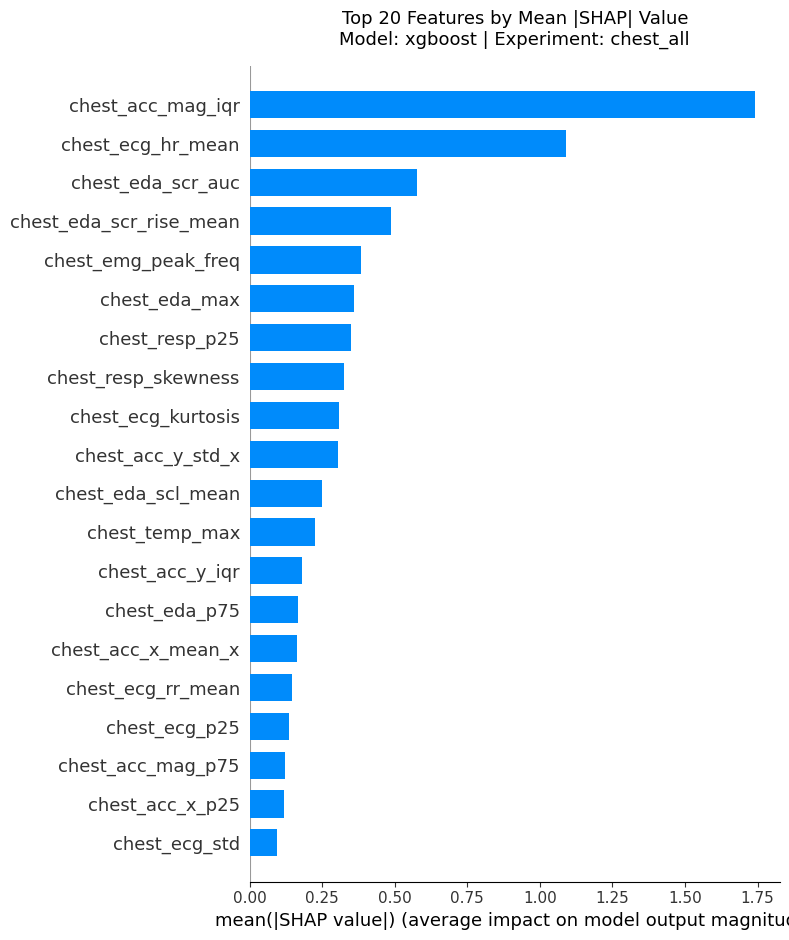


 Bar plot saved


In [31]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_scaled_df,
    plot_type="bar",           # Bar chart of mean |SHAP| per feature
    max_display=20,            # Show top 20 features
    show=False
)
plt.title(f"Top 20 Features by Mean |SHAP| Value\nModel: {MODEL_NAME} | Experiment: {EXPERIMENT}",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(f"shap_bar_{MODEL_NAME}_{EXPERIMENT}.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Bar plot saved")

## Cell 8:  Beeswarm (Summary) Plot  Direction & Distribution

**What it shows:** Every single sample as a dot. The color shows the feature value (red = high, blue = low).  

**How to read it:**
- A feature with **red dots on the right** → high values of that feature **increase stress** prediction
- A feature with **blue dots on the right** → low values of that feature **increase stress** prediction
- Wide spread → this feature has high variability in impact across samples

**Example interpretation:**  
> `eda_mean` has red dots on the right -> high skin conductance (EDA) strongly predicts stress ->  makes physiological sense!

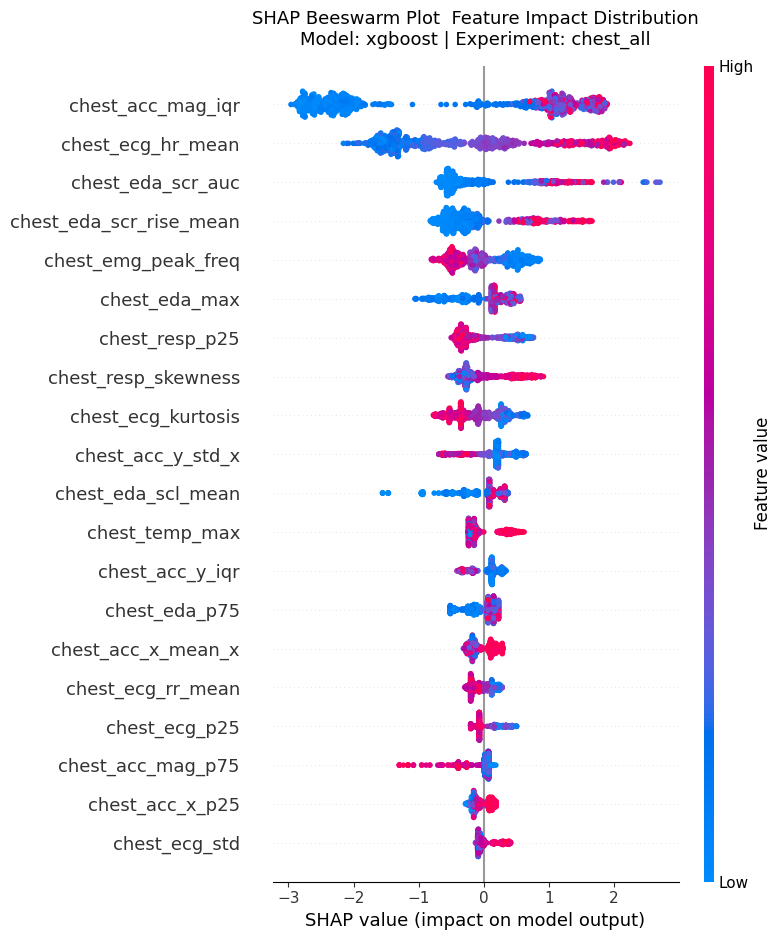


 Beeswarm plot saved


In [41]:
plt.figure(figsize=(10, 9))
shap.summary_plot(
    shap_values,
    X_scaled_df,
    plot_type="dot",           # Beeswarm / dot plot (default)
    max_display=20,
    show=False
)
plt.title(f"SHAP Beeswarm Plot  Feature Impact Distribution\nModel: {MODEL_NAME} | Experiment: {EXPERIMENT}",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(f"shap_beeswarm_{MODEL_NAME}_{EXPERIMENT}.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n Beeswarm plot saved")

## Cell 9: Heatmap — Feature Impact Across All Samples

**What it shows:** SHAP values as a heatmap: rows = features, columns = samples (sorted by prediction).  
**How to read it:** Patterns running vertically tell you which samples are "hard cases" or outliers.

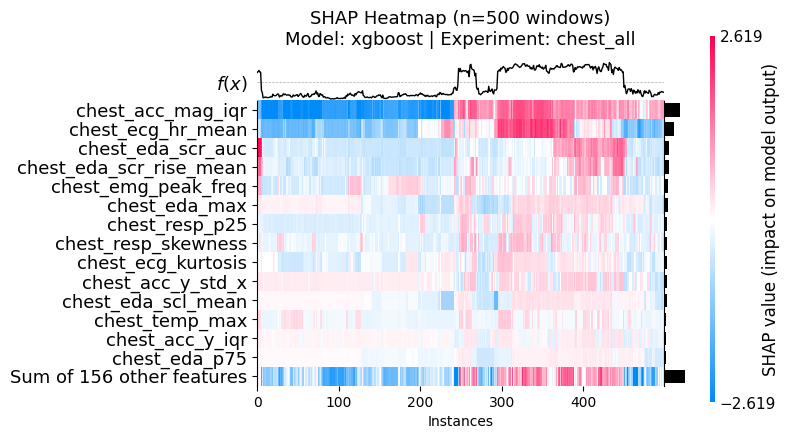

 Heatmap saved


In [33]:
# Sample 500 windows for readability (full dataset may be too dense)
SAMPLE_SIZE = min(500, len(X_scaled_df))
idx_sample  = np.random.choice(len(X_scaled_df), SAMPLE_SIZE, replace=False)

plt.figure(figsize=(14, 8))
shap.plots.heatmap(
    shap_explanation[idx_sample],
    max_display=15,
    show=False
)
plt.title(f"SHAP Heatmap (n={SAMPLE_SIZE} windows)\nModel: {MODEL_NAME} | Experiment: {EXPERIMENT}",
          fontsize=13)
plt.tight_layout()
plt.savefig(f"shap_heatmap_{MODEL_NAME}_{EXPERIMENT}.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap saved")

## Cell 10:  Waterfall Plot  Explain One Prediction

**What it shows:** A single sample's prediction broken down step-by-step.  
**How to read it:**
- Starts from the **base value** (average model output)
- Each feature either **pushes right (-> stress)** or **pushes left (-> baseline)**
- The final value is the model's actual prediction for this sample

This is the most intuitive explanation for a single person's stress reading.

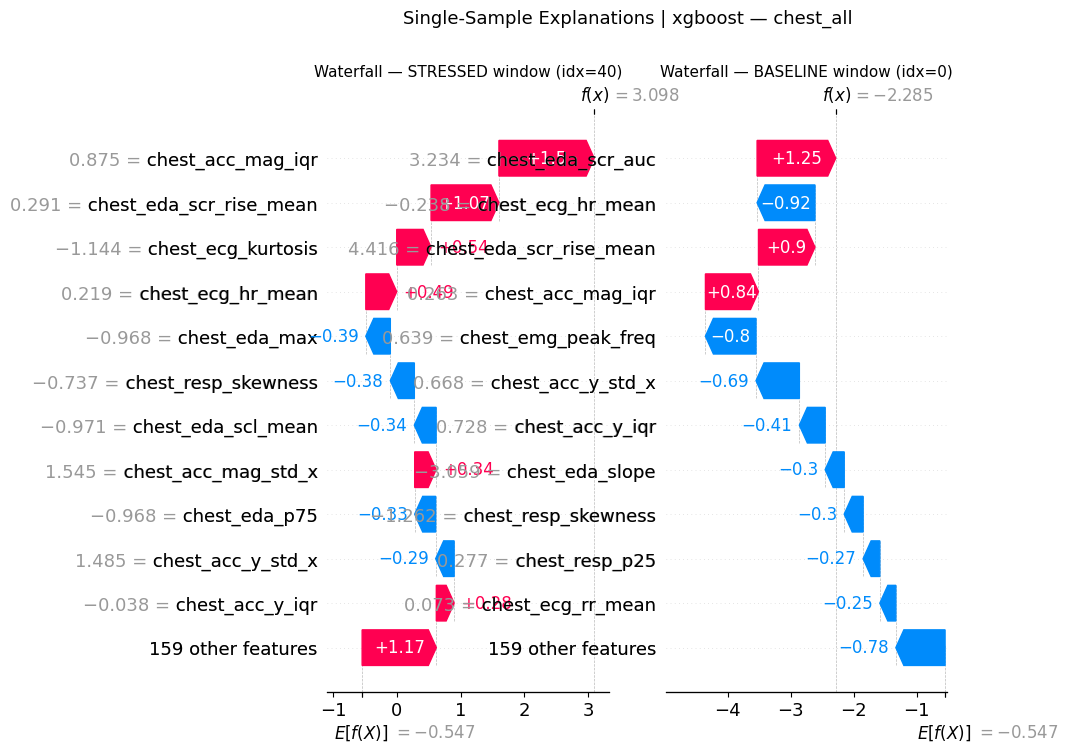

 Waterfall plots saved


In [34]:
# Pick one stressed sample and one baseline sample to compare
stressed_indices  = np.where(y.values == 1)[0]
baseline_indices  = np.where(y.values == 0)[0]

# Index of the sample to explain
SAMPLE_IDX_STRESS   = stressed_indices[0]   # First stressed window
SAMPLE_IDX_BASELINE = baseline_indices[0]   # First baseline window

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, idx, label in [
    (axes[0], SAMPLE_IDX_STRESS,   "STRESSED"),
    (axes[1], SAMPLE_IDX_BASELINE, "BASELINE")
]:
    plt.sca(ax)
    shap.plots.waterfall(shap_explanation[idx], max_display=12, show=False)
    ax.set_title(f"Waterfall — {label} window (idx={idx})", fontsize=11)

plt.suptitle(f"Single-Sample Explanations | {MODEL_NAME} — {EXPERIMENT}",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"shap_waterfall_{MODEL_NAME}_{EXPERIMENT}.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Waterfall plots saved")

## Cell 11:  Force Plot — Interactive Single-Sample Explanation

**What it shows:** Same as waterfall but rendered as an interactive HTML widget.  
- **Red arrows** = features pushing toward stress  
- **Blue arrows** = features pushing toward baseline  
- Arrow width = magnitude of contribution  



 Force plot for STRESSED window 


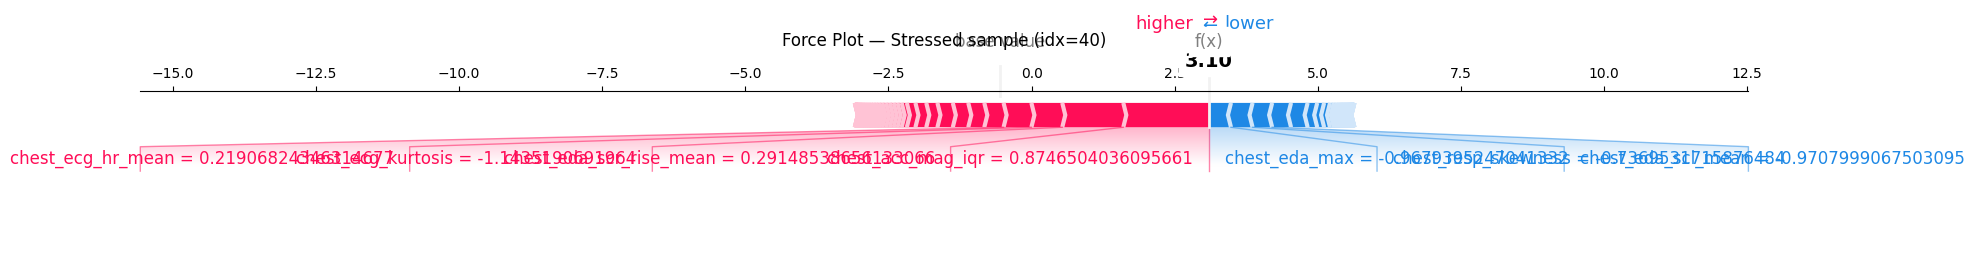


 Force plot for BASELINE window


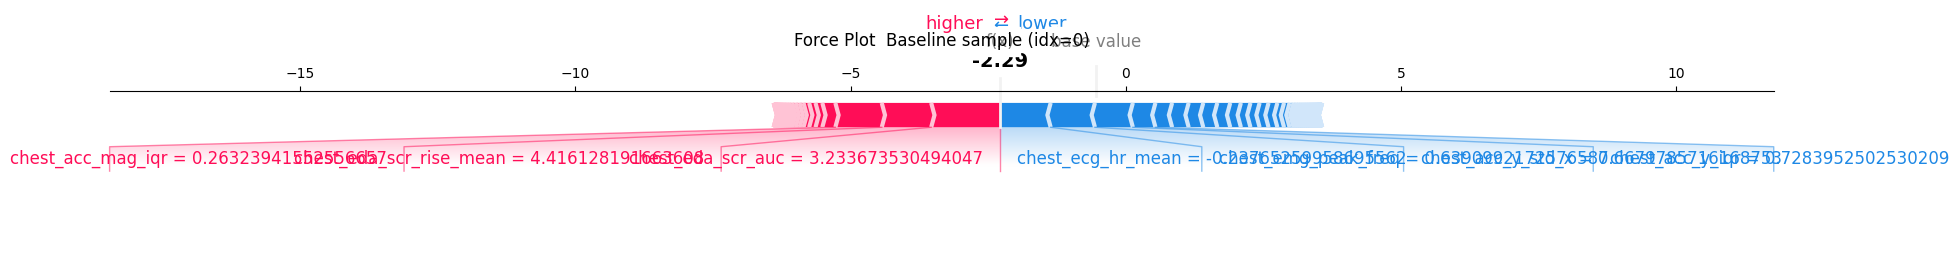

 Force plots saved


In [35]:
print(" Force plot for STRESSED window ")
shap.force_plot(
    explainer.expected_value,
    shap_values[SAMPLE_IDX_STRESS],
    X_scaled_df.iloc[SAMPLE_IDX_STRESS],
    matplotlib=True,      # Static version for saving
    show=False
)
plt.title(f"Force Plot — Stressed sample (idx={SAMPLE_IDX_STRESS})", pad=15)
plt.tight_layout()
plt.savefig(f"shap_force_stress_{MODEL_NAME}_{EXPERIMENT}.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n Force plot for BASELINE window")
shap.force_plot(
    explainer.expected_value,
    shap_values[SAMPLE_IDX_BASELINE],
    X_scaled_df.iloc[SAMPLE_IDX_BASELINE],
    matplotlib=True,
    show=False
)
plt.title(f"Force Plot  Baseline sample (idx={SAMPLE_IDX_BASELINE})", pad=15)
plt.tight_layout()
plt.savefig(f"shap_force_baseline_{MODEL_NAME}_{EXPERIMENT}.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Force plots saved")

## Cell 12:  SHAP Dependence Plot Feature Interactions

**What it shows:** How a specific feature's value relates to its SHAP contribution.  
The coloring reveals interactions with a second feature (auto-selected by SHAP).

**How to read it:**
- X-axis = feature value (standardized)
- Y-axis = SHAP value (impact on prediction)
- If the curve is not monotone -> the feature has non-linear or conditional effects
- Color = a second feature's value clustering by color = interaction effect

> Change `TOP_FEATURE` below to plot for any feature you're curious about.

"Top 4 features by mean |SHAP|: ['chest_acc_mag_iqr', 'chest_ecg_hr_mean', 'chest_eda_scr_auc', 'chest_eda_scr_rise_mean']"

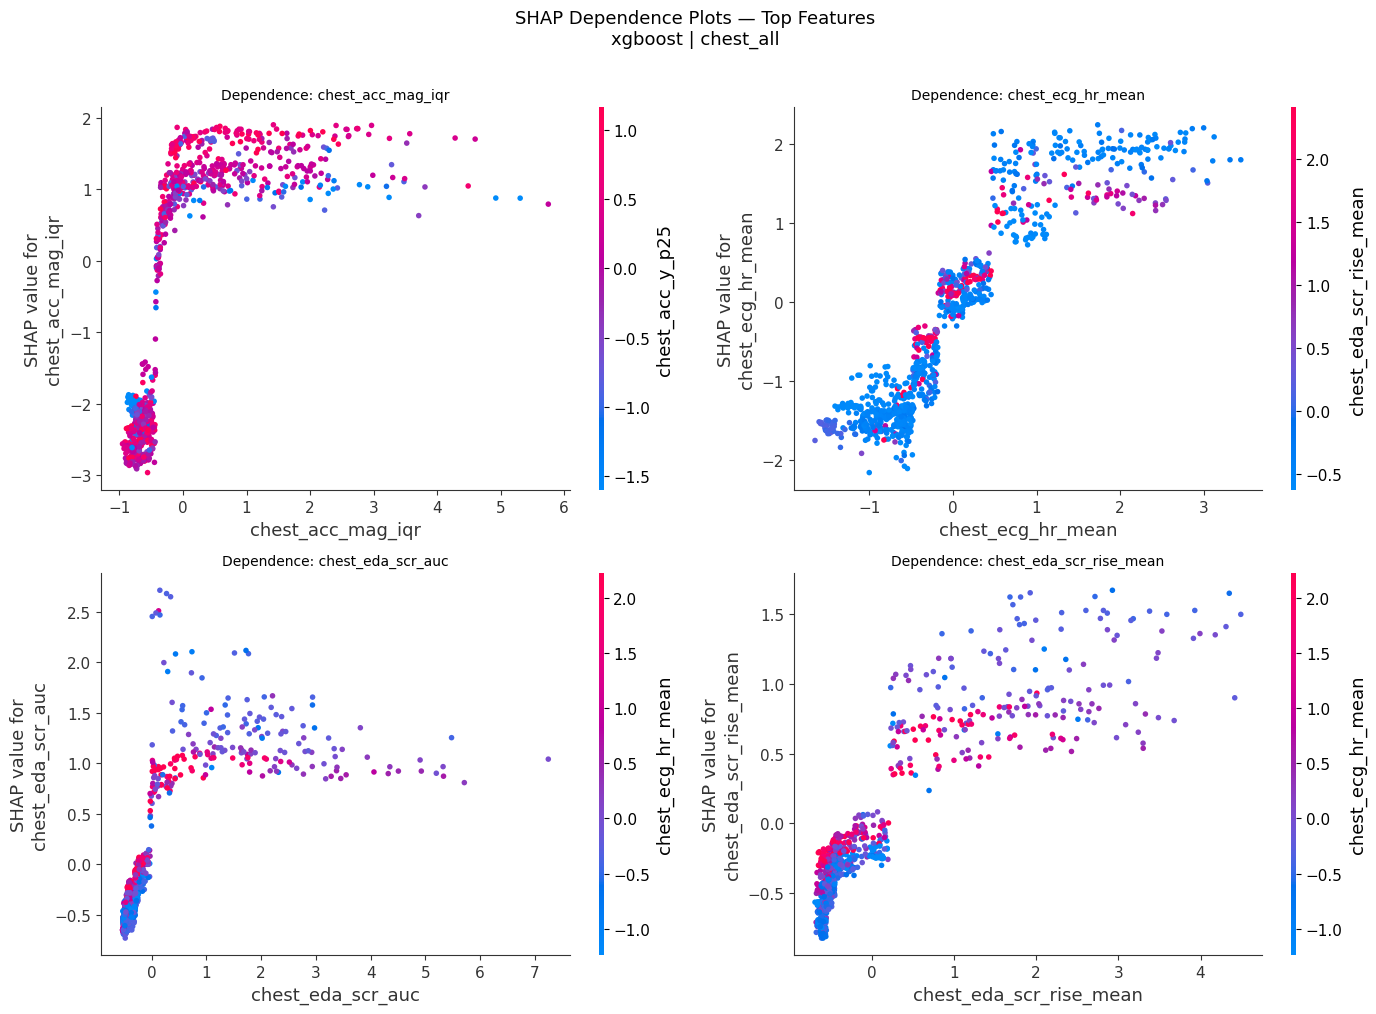

 Dependence plots saved


In [36]:
# Auto-select the top 2 features by mean |SHAP|
mean_shap    = np.abs(shap_values).mean(axis=0)
top_features = pd.Series(mean_shap, index=feature_names).nlargest(4).index.tolist()

display(f"Top 4 features by mean |SHAP|: {top_features}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    plt.sca(axes[i])
    shap.dependence_plot(
        feat,
        shap_values,
        X_scaled_df,
        interaction_index="auto",  # Auto-pick most interacting feature for color
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f"Dependence: {feat}", fontsize=10)

plt.suptitle(f"SHAP Dependence Plots — Top Features\n{MODEL_NAME} | {EXPERIMENT}",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"shap_dependence_{MODEL_NAME}_{EXPERIMENT}.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Dependence plots saved")

## Cell 13:  SHAP Feature Importance Table

Export a clean DataFrame with all features ranked by their mean absolute SHAP value.  
Useful for reports or filtering features for a lighter model.

In [37]:
# Build a ranked importance table
mean_abs_shap = np.abs(shap_values).mean(axis=0)
mean_shap_dir = shap_values.mean(axis=0)          # Signed: positive = toward stress

shap_importance_df = pd.DataFrame({
    "feature":          feature_names,
    "mean_abs_shap":    mean_abs_shap,
    "mean_shap_signed": mean_shap_dir,             # + = stress, - = baseline
    "direction":        ["stress" if v > 0 else " baseline" for v in mean_shap_dir],
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_importance_df.index += 1   # 1-based rank
shap_importance_df.index.name = "rank"

print(f"Top 20 features (SHAP-ranked) for {MODEL_NAME} / {EXPERIMENT}")
print("=" * 65)
print(shap_importance_df.head(20).to_string())

# Save to CSV
csv_path = f"shap_importance_{MODEL_NAME}_{EXPERIMENT}.csv"
shap_importance_df.to_csv(csv_path)
print(f"\n Saved to {csv_path}")

Top 20 features (SHAP-ranked) for xgboost / chest_all
                      feature  mean_abs_shap  mean_shap_signed  direction
rank                                                                     
1           chest_acc_mag_iqr       1.740245         -0.532562   baseline
2           chest_ecg_hr_mean       1.089992         -0.258444   baseline
3           chest_eda_scr_auc       0.576899         -0.078821   baseline
4     chest_eda_scr_rise_mean       0.486382         -0.118097   baseline
5         chest_emg_peak_freq       0.383558         -0.034650   baseline
6               chest_eda_max       0.359559          0.004795     stress
7              chest_resp_p25       0.350954         -0.087153   baseline
8         chest_resp_skewness       0.324910         -0.035419   baseline
9          chest_ecg_kurtosis       0.307603         -0.074374   baseline
10          chest_acc_y_std_x       0.305743          0.153633     stress
11         chest_eda_scl_mean       0.248124         -0.00

## Cell 14:  Compare SHAP Across Experiments

Run SHAP for multiple experiments and compare top-10 features side by side.  
This helps answer: **Does chest vs wrist EDA have different importance profiles?**

> This cell will recompute SHAP for each selected experiment — may take a few minutes.


Processing chest_all...
   Done  top feature: chest_acc_mag_iqr

Processing wrist_all...
   Done  top feature: wrist_bvp_hr_mean


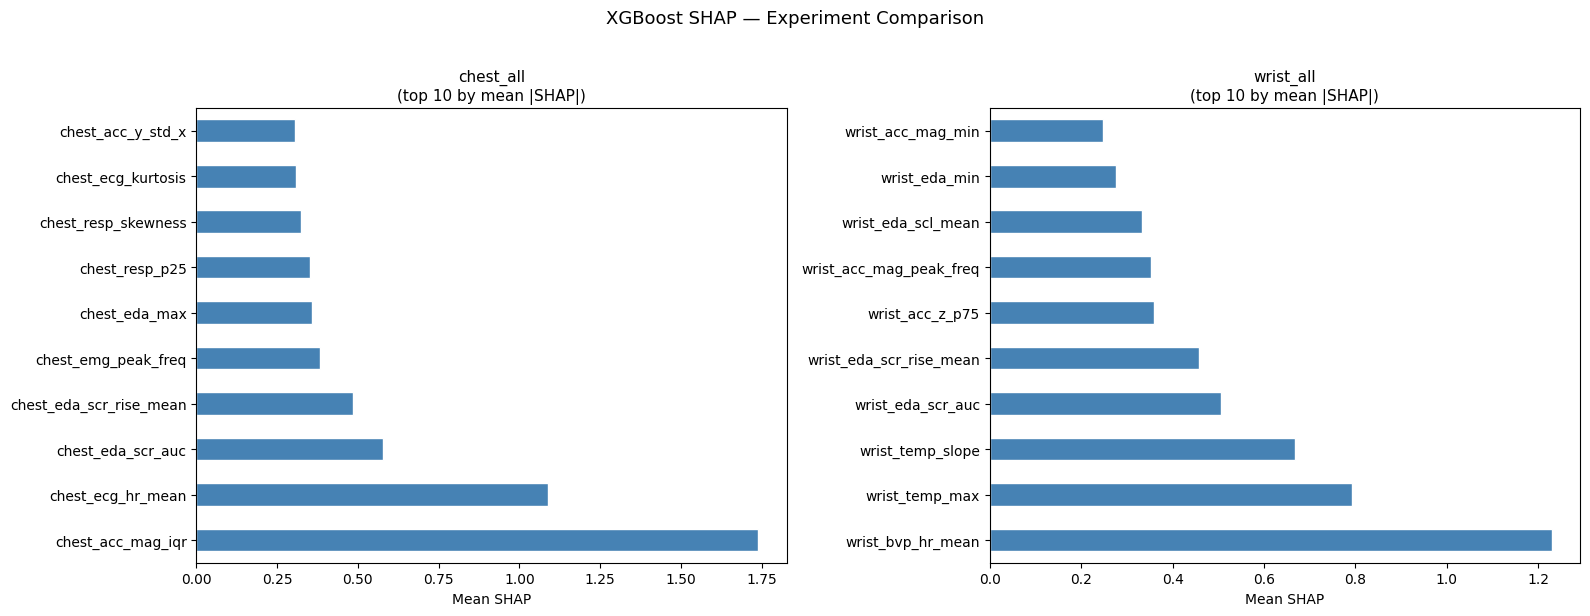

 Comparison plot saved


In [38]:
# Experiments to compare  dynamic as of now but needed hardcoding
COMPARE_EXPERIMENTS = ["chest_all", "wrist_all"]

comparison_data = {}  # exp_name top 10 feature importance series

for exp in COMPARE_EXPERIMENTS:
    print(f"\nProcessing {exp}...")
    try:
        # Load model & data for this experiment
        m, sc, med, mt = load_production_model(MODEL_NAME, exp)
        df_exp = load_dataset(EXPERIMENT_CONFIGS[exp])

        X_r = df_exp.drop(columns=NON_FEATURE_COLS)
        X_i = X_r[mt["feature_names"]].fillna(med)
        X_s = sc.transform(X_i)
        X_s_df = pd.DataFrame(X_s, columns=mt["feature_names"])

        exp_explainer = shap.TreeExplainer(m)
        sv = exp_explainer.shap_values(X_s_df)

        top10 = pd.Series(np.abs(sv).mean(axis=0), index=mt["feature_names"]).nlargest(10)
        comparison_data[exp] = top10
        print(f"   Done  top feature: {top10.index[0]}")

    except FileNotFoundError:
        print(f"    Skipping {exp}  model not found. Train it first debuging line something seomthing.")

if comparison_data:
    # Plot side-by-side bars
    n_plots = len(comparison_data)
    fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 6), squeeze=False)

    for ax, (exp_name, top10) in zip(axes[0], comparison_data.items()):
        top10.sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
        ax.set_title(f"{exp_name}\n(top 10 by mean |SHAP|)", fontsize=11)
        ax.set_xlabel("Mean SHAP")
        ax.invert_yaxis()

    plt.suptitle(f"XGBoost SHAP — Experiment Comparison", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f"shap_comparison_{'_vs_'.join(comparison_data.keys())}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print(" Comparison plot saved")

## Cell 15:  SHAP by Subject — Who is Most/Least Explainable?

Break down mean absolute SHAP by subject.  
High SHAP variance across subjects = the model relies on different features per person — may indicate subject-specific patterns or poor generalization.

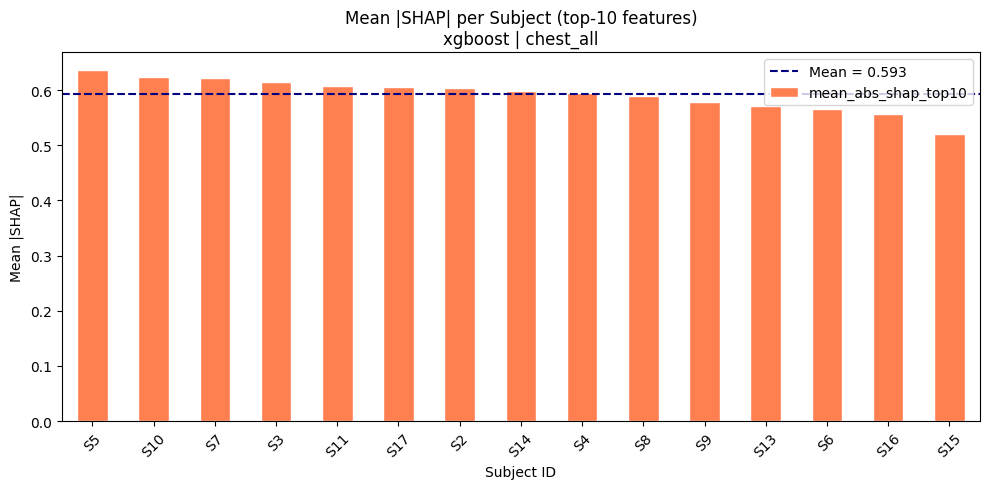

📌 Per-subject SHAP plot saved


In [39]:
# Reload original experiment data (cell 5)
df_reload  = load_dataset(DATA_CONFIG)
subjects   = df_reload["subject"].values
unique_sub = np.unique(subjects)

# Mean |SHAP| per subject (over top 10 features)
top10_features = shap_importance_df.head(10)["feature"].tolist()
top10_idx      = [feature_names.index(f) for f in top10_features]

sub_shap = {}
for s in unique_sub:
    mask = subjects == s
    sub_shap[s] = np.abs(shap_values[mask][:, top10_idx]).mean()

sub_df = pd.Series(sub_shap, name="mean_abs_shap_top10").sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sub_df.plot(kind="bar", color="coral", edgecolor="white")
plt.axhline(sub_df.mean(), color="navy", linestyle="--", label=f"Mean = {sub_df.mean():.3f}")
plt.title(f"Mean |SHAP| per Subject (top-10 features)\n{MODEL_NAME} | {EXPERIMENT}", fontsize=12)
plt.xlabel("Subject ID")
plt.ylabel("Mean |SHAP|")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"shap_per_subject_{MODEL_NAME}_{EXPERIMENT}.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Per-subject SHAP plot saved")

## Cell 16:  Summary & Interpretation Guide
getting our all findings into a clean csv file


In [40]:
top5 = shap_importance_df.head(5)

display(f"  SHAP SUMMARY: {MODEL_NAME.upper()} / {EXPERIMENT}")
display("=" * 60)
display(f"\n  Dataset  : {meta['n_subjects']} subjects, {meta['n_windows']} windows")
display(f"  Features : {meta['n_features']} total")
display(f"  Base rate: {explainer.expected_value:.4f} (model's average log-odds)")

display("\n  TOP 5 MOST IMPORTANT FEATURES:")
display("  " + "-" * 55)
for rank, row in top5.iterrows():
    print(f"  {rank}. {row['feature']:<35} | {row['mean_abs_shap']:.4f} | {row['direction']}")

display("\n  INTERPRETATION TIPS:")
display("   Features with ' stress' on average increase stress predictions")
display("   Check the Beeswarm plot — red on right = high value = more stress")
display("   Dependence plots reveal non-linear or conditional effects")
display("   Waterfall plots explain individual windows (useful for debugging)")
display("   Per-subject SHAP shows if the model generalises uniformly")

print("\n  FILES SAVED:")
import glob
for f in sorted(glob.glob(f"shap_*_{MODEL_NAME}_{EXPERIMENT}*")):
    print(f"   {f}")

'  SHAP SUMMARY: XGBOOST / chest_all'

'============================================================'

'\n  Dataset  : 15 subjects, 975 windows'

'  Features : 170 total'

"  Base rate: -0.5466 (model's average log-odds)"

'\n  TOP 5 MOST IMPORTANT FEATURES:'

'  -------------------------------------------------------'

  1. chest_acc_mag_iqr                   | 1.7402 |  baseline
  2. chest_ecg_hr_mean                   | 1.0900 |  baseline
  3. chest_eda_scr_auc                   | 0.5769 |  baseline
  4. chest_eda_scr_rise_mean             | 0.4864 |  baseline
  5. chest_emg_peak_freq                 | 0.3836 |  baseline


'\n  INTERPRETATION TIPS:'

"   Features with ' stress' on average increase stress predictions"

'   Check the Beeswarm plot — red on right = high value = more stress'

'   Dependence plots reveal non-linear or conditional effects'

'   Waterfall plots explain individual windows (useful for debugging)'

'   Per-subject SHAP shows if the model generalises uniformly'


  FILES SAVED:
   shap_bar_xgboost_chest_all.png
   shap_beeswarm_xgboost_chest_all.png
   shap_dependence_xgboost_chest_all.png
   shap_force_baseline_xgboost_chest_all.png
   shap_force_stress_xgboost_chest_all.png
   shap_heatmap_xgboost_chest_all.png
   shap_importance_xgboost_chest_all.csv
   shap_per_subject_xgboost_chest_all.png
   shap_waterfall_xgboost_chest_all.png


---

## Quick Reference: SHAP Plots 

| Plot | Scope | What it answers |
|------|-------|----------------|
| **Bar** | Global | Which features matter most overall? |
| **Beeswarm** | Global | How do feature values relate to impact? |
| **Heatmap** | All samples | Which samples are unusual? |
| **Waterfall** | 1 sample | Why was THIS window predicted stressed? |
| **Force** | 1 sample | Same as waterfall, visual format |
| **Dependence** | 1 feature | Is the effect linear? Any interactions? |

##  Next Steps

1. **Feature selection**: Drop features with near-zero SHAP values → retrain a leaner model
2. **Sanity check**: Do top SHAP features align with physiological knowledge? (EDA, HR should be top)
3. **Subject analysis**: If one subject has very different SHAP profile → check their data quality
4. **Compare with LOSO**: Run SHAP on per-fold models from `benchmark.py` to see if importance is stable across folds